# 03 · Model Training & Evaluation
Out-of-time split → Ridge baseline, XGBoost (main), LightGBM (benchmark), and a conformalized quantile interval. Then SHAP attribution and calibration.

In [1]:
import os, sys
ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
os.chdir(ROOT); sys.path.insert(0, ROOT)
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.max_columns', 30); pd.set_option('display.width', 120)
%matplotlib inline

In [2]:
from src.config import load_config
from src.training import prepare_training_frame, out_of_time_split
from src.features.pipeline import FeaturePipeline
from src.models import RidgeBaseline, XGBoostRegressorModel, LightGBMBenchmark, \
    QuantileIntervalModel, regression_metrics, interval_coverage
cfg = load_config()
df = prepare_training_frame(cfg)
train, val, test = out_of_time_split(df, cfg.model.val_fraction, cfg.model.test_fraction)
pipe = FeaturePipeline(50); Xtr = pipe.fit_transform(train)
Xva, Xte = pipe.transform(val), pipe.transform(test)
ytr, yva, yte = train.price.values, val.price.values, test.price.values
print('train/val/test:', len(train), len(val), len(test))

train/val/test: 7118 1524 1524


### Model comparison (held-out test set)

In [3]:
rows = []
for name, mdl in [('Ridge (baseline)', RidgeBaseline()),
                  ('XGBoost (main)', XGBoostRegressorModel(cfg.model.xgboost)),
                  ('LightGBM (benchmark)', LightGBMBenchmark())]:
    mdl.fit(Xtr, ytr)
    rows.append({'model': name, **regression_metrics(yte, mdl.predict(Xte))})
    if name.startswith('XGBoost'): xgb = mdl
pd.DataFrame(rows).set_index('model').round({'mae':1,'mape':1,'r2':3})

,mae,mape,r2,n
model,,,,
Ridge (baseline),82.3,24.5,0.543,1524
XGBoost (main),76.4,23.2,0.602,1524
LightGBM (benchmark),81.2,24.0,0.543,1524


### Conformalized quantile intervals (80%)
Raw quantile regressors under-cover; CQR calibration on the validation set restores nominal coverage.

In [4]:
q = QuantileIntervalModel(0.1, 0.9).fit(Xtr, ytr)
lo0, hi0 = q.predict_interval(Xte); cov0 = interval_coverage(yte, lo0, hi0)
q.calibrate(Xva, yva)
lo, hi = q.predict_interval(Xte); cov = interval_coverage(yte, lo, hi)
print(f'coverage before CQR: {cov0:.1%}  ->  after CQR: {cov:.1%}  (nominal 80%)')

coverage before CQR: 57.3%  ->  after CQR: 68.5%  (nominal 80%)


### Predicted vs actual & residuals

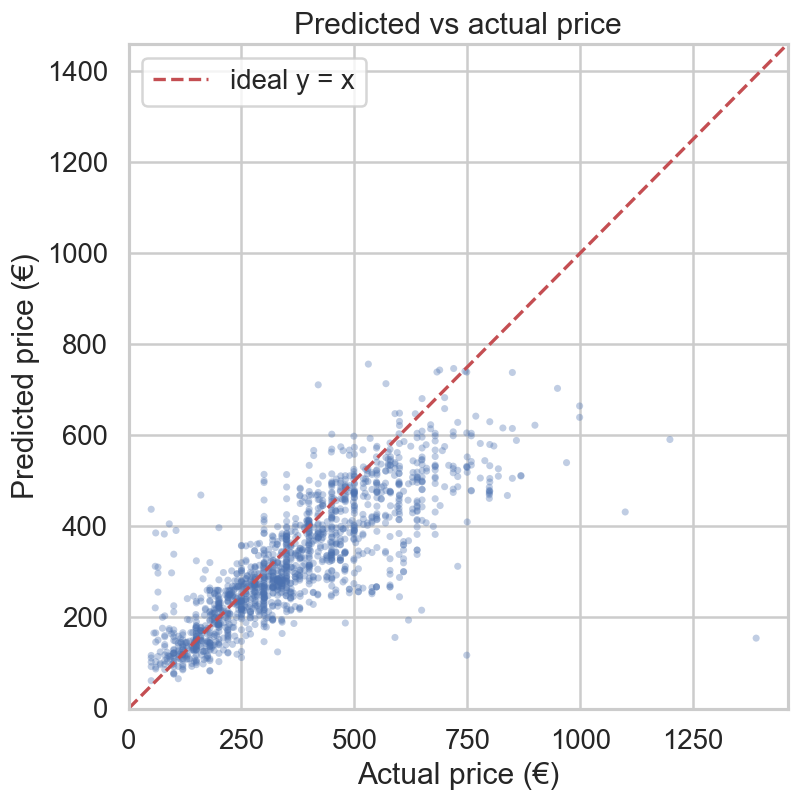

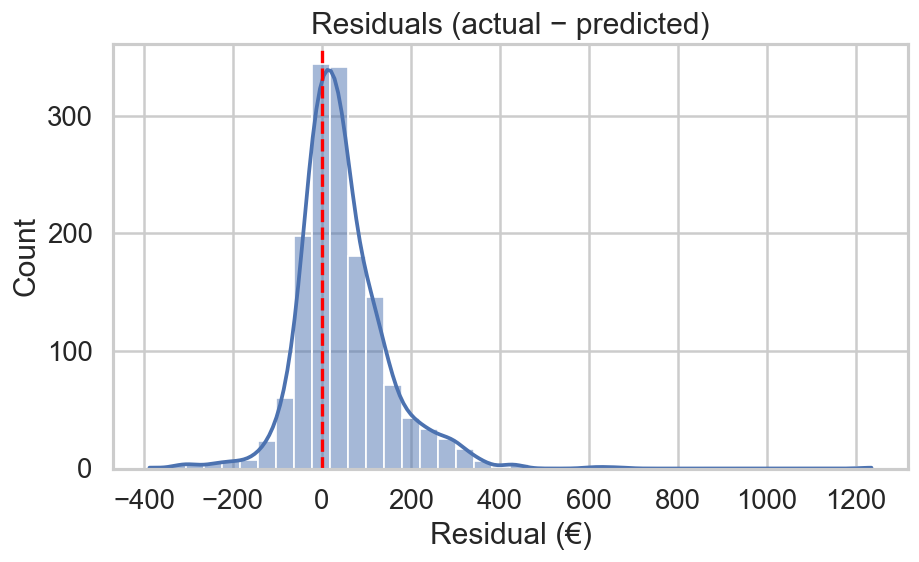

In [5]:
from src.reporting import viz
yp = xgb.predict(Xte)
p1 = viz.predicted_vs_actual(yte, yp, 'artifacts/reports/nb_pva.png')
p2 = viz.residual_hist(yte, yp, 'artifacts/reports/nb_resid.png')
from IPython.display import Image, display; display(Image(str(p1)), Image(str(p2)))

### SHAP feature attribution (S7)
Why the model predicts what it does. We use XGBoost's exact native tree-SHAP (`pred_contribs`), which is both fast and avoids a version mismatch in the standalone SHAP loader.

In [6]:
import shap, xgboost as xgb_lib
sample = Xte.iloc[:300]
contribs = xgb.estimator.get_booster().predict(xgb_lib.DMatrix(sample), pred_contribs=True)
sv = contribs[:, :-1]   # drop the bias column
shap.summary_plot(sv, sample, plot_type='bar', max_display=12, show=False)
plt.tight_layout(); plt.show()